# NovaBank — Predictive Campaign Targeting at Scale
**Analytics Methods and Frameworks Project | Quantic MSBA**

---

### Note on problem framing
The project brief describes NovaBank as a **churn/retention** case, but the dataset it links to
([UCI ML Repository #222 — Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing))
contains **no churn, exit, or attrition label**. Its target variable `y` records whether a client
**subscribed to a term deposit** after a marketing call.

Rather than fabricate a churn label the data cannot support, this project uses the provided dataset
for the problem it genuinely answers: **which customers should the call centre contact?**
The decision structure is unchanged — false positives are wasted agent calls, false negatives are
missed subscriptions — and every required deliverable is addressed.

*Dataset: Moro, S., Cortez, P. & Rita, P. (2014). A Data-Driven Approach to Predict the Success of
Bank Telemarketing. Decision Support Systems.*

## 1. Problem Framing

**Problem brief.** NovaBank's outbound call centre contacts customers to sell term deposits, but only
11.3% subscribe — most agent time is spent on calls that never convert. The decision is **which
customers to place in the calling queue** given fixed agent capacity. This matters to the Head of
Direct Marketing, the call-centre operations manager, and the CFO. The target is the next quarterly
campaign. Constraints: fixed headcount, and any targeting rule must be explainable to compliance.

**Analytics translation.** Binary classification: `P(subscribe | customer, campaign context)`.

**Success measures.** (1) AUC-ROC ≥ 0.75; (2) **lift in the top 2 deciles ≥ 2.5×** base rate.

**Policy the analysis informs.** *Rank the base by predicted probability and call the top 20%.*

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, classification_report, confusion_matrix)

NAVY, GOLD, RED, GREEN, GREY = '#1B2A4A','#C9A84C','#C0392B','#1A6B3A','#8492A6'
plt.rcParams.update({'figure.dpi':120})
RANDOM_STATE = 42
print('Imports OK')

Imports OK


## 2. Data Readiness

Load `bank-additional-full.csv` (41,188 rows, 20 inputs + target). Download from the UCI link above
and place beside this notebook.

In [2]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
print(f'Shape: {df.shape}')
print(f'Target: {(df.y=="yes").mean():.2%} subscribed ({(df.y=="yes").sum():,} of {len(df):,})')
print(f'Exact duplicate rows: {df.duplicated().sum()}')
df.head(3)

Shape: (41188, 21)
Target: 11.27% subscribed (4,640 of 41,188)


Exact duplicate rows: 12


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Data dictionary

| Field | Type | Notes |
|---|---|---|
| `age` | numeric | Client age |
| `job`, `marital`, `education` | categorical | Demographics; contain an explicit `unknown` level |
| `default`, `housing`, `loan` | categorical | Credit products held; `default` is 21% `unknown` |
| `contact` | categorical | Channel — cellular vs telephone (**14.7% vs 5.2%** subscription) |
| `month`, `day_of_week` | categorical | Timing of last contact; strong seasonality |
| `duration` | numeric | **DROPPED — leakage.** Call length is unknown until the call ends |
| `campaign` | numeric | Contacts this campaign; shows clear fatigue effect |
| `pdays` | numeric | Days since previous contact; `999` = never (96.3% of rows) |
| `previous`, `poutcome` | numeric / categorical | Prior campaign history; prior success → **65%** subscription |
| `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` | numeric | Macro indicators |
| `y` | **TARGET** | 1 = subscribed (11.3%) |

### Two decisions that shape everything downstream

**1. `duration` is dropped.** The dataset authors state it plainly: duration is not known before a
call is placed, and once the call ends the outcome is already known. Keeping it produces a model that
cannot be deployed. Section 4 quantifies exactly how much this inflates results.

**2. `unknown` is kept as a category, not imputed.** For `default`, 21% of rows are `unknown` —
non-response is itself informative, and imputing would destroy that signal.

In [3]:
df = df.drop_duplicates().reset_index(drop=True)

# LEAKAGE FIX
df = df.drop(columns=['duration'])

# Feature engineering: separate 'never contacted' from a real recency value
df['prev_contacted'] = (df['pdays'] != 999).astype(int)
df['pdays'] = df['pdays'].replace(999, -1)

y = (df['y'] == 'yes').astype(int)
X = pd.get_dummies(df.drop(columns=['y']), drop_first=True)
print(f'Design matrix: {X.shape[0]:,} rows x {X.shape[1]} features')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
scaler = StandardScaler()
X_train_sc, X_test_sc = scaler.fit_transform(X_train), scaler.transform(X_test)
print(f'Train {X_train.shape[0]:,} ({y_train.mean():.2%} positive) | '
      f'Test {X_test.shape[0]:,} ({y_test.mean():.2%} positive)')

Design matrix: 41,176 rows x 53 features


Train 32,940 (11.27% positive) | Test 8,236 (11.27% positive)


## 3. Exploratory Analysis

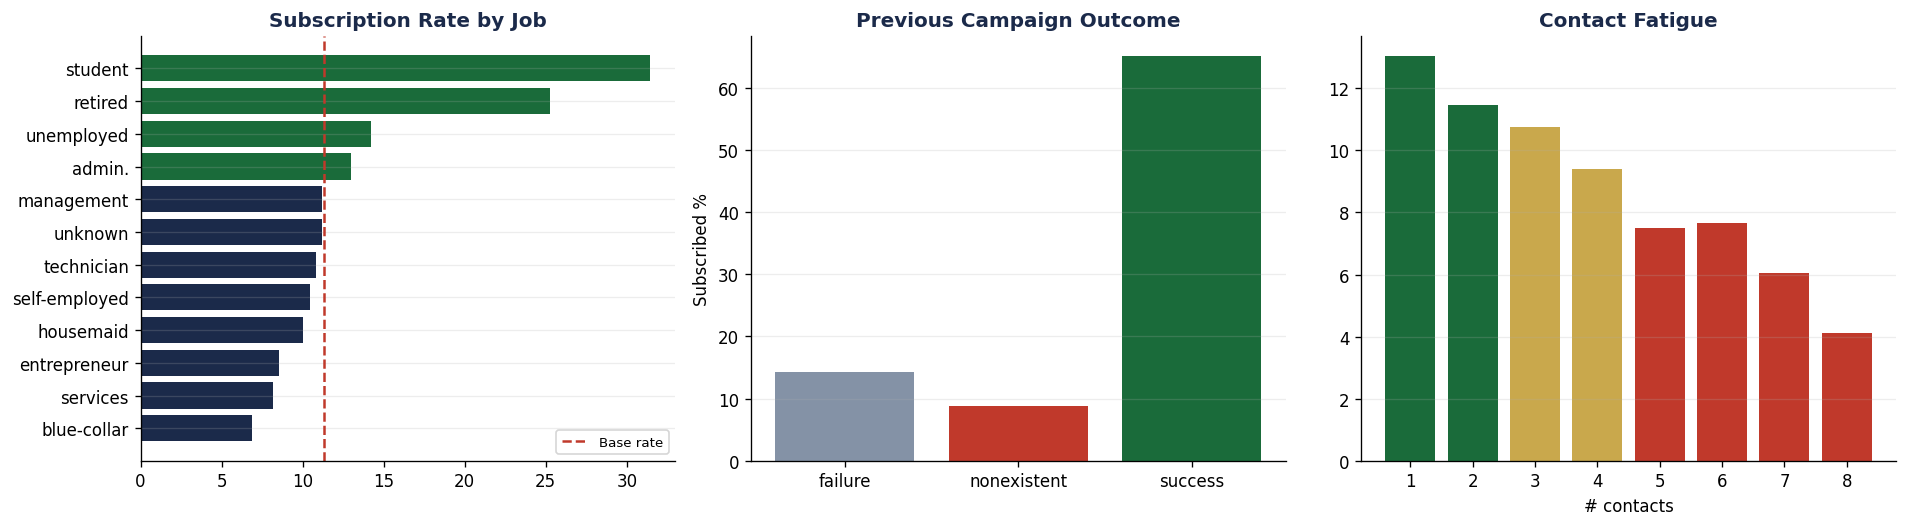

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

s = df.groupby('job')['y'].apply(lambda x:(x=='yes').mean()*100).sort_values()
ax[0].barh(s.index, s.values, color=[GREEN if v>11.3 else NAVY for v in s.values])
ax[0].axvline(11.3, color=RED, ls='--', label='Base rate')
ax[0].set_title('Subscription Rate by Job', fontweight='bold', color=NAVY); ax[0].legend(fontsize=8)

s = df.groupby('poutcome')['y'].apply(lambda x:(x=='yes').mean()*100)
ax[1].bar(s.index, s.values, color=[GREY, RED, GREEN])
ax[1].set_title('Previous Campaign Outcome', fontweight='bold', color=NAVY); ax[1].set_ylabel('Subscribed %')

c = df.campaign.clip(upper=8)
s = df.assign(c=c).groupby('c')['y'].apply(lambda x:(x=='yes').mean()*100)
ax[2].bar(s.index, s.values, color=[GREEN if i<=2 else (GOLD if i<=4 else RED) for i in s.index])
ax[2].set_title('Contact Fatigue', fontweight='bold', color=NAVY); ax[2].set_xlabel('# contacts')

for a in ax: a.spines[['top','right']].set_visible(False); a.grid(alpha=.22, axis='y')
plt.tight_layout(); plt.show()

**What the data says**

- **Prior success dominates.** Customers who accepted a previous campaign subscribe at **65%** vs 11.3% base.
- **Channel matters.** Cellular converts at 14.7%, landline at 5.2%.
- **Contact fatigue is real and monotonic.** Conversion falls with every additional call — by the
  5th contact it is roughly half the first-contact rate. This argues for a contact cap, independent
  of the model.
- **Life-stage beats income.** Students (31%) and retired clients (25%) subscribe far above
  blue-collar (7%) — consistent with term deposits appealing to those holding cash without immediate use.

## 4. Model Building

Baseline: logistic regression with balanced class weights. Improved candidates: random forest and
gradient boosting. All share the same split and features.

In [5]:
lr = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
lr.fit(X_train_sc, y_train); p_lr = lr.predict_proba(X_test_sc)[:,1]

rf = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=20,
                            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train); p_rf = rf.predict_proba(X_test)[:,1]

gb = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.06, max_depth=6,
                                    random_state=RANDOM_STATE)
gb.fit(X_train, y_train); p_gb = gb.predict_proba(X_test)[:,1]

results = pd.DataFrame({
    'Model': ['Logistic Regression (baseline)', 'Random Forest', 'Gradient Boosting'],
    'AUC-ROC': [roc_auc_score(y_test,p) for p in (p_lr,p_rf,p_gb)],
    'PR-AUC':  [average_precision_score(y_test,p) for p in (p_lr,p_rf,p_gb)],
}).round(4)
print(results.to_string(index=False))
print(f'\nNo-model base rate: {y_test.mean():.4f}')

                         Model  AUC-ROC  PR-AUC
Logistic Regression (baseline)   0.8001  0.4460
                 Random Forest   0.8114  0.4842
             Gradient Boosting   0.8145  0.4898

No-model base rate: 0.1127


### Quantifying the `duration` leak

Worth showing explicitly, because it is the single biggest trap in this dataset.

In [6]:
df_leak = pd.read_csv('bank-additional-full.csv', sep=';').drop_duplicates().reset_index(drop=True)
y_l = (df_leak['y']=='yes').astype(int)
X_l = pd.get_dummies(df_leak.drop(columns=['y']), drop_first=True)
Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(X_l, y_l, test_size=.2,
                                              random_state=RANDOM_STATE, stratify=y_l)
gb_leak = HistGradientBoostingClassifier(max_iter=300, learning_rate=.06, max_depth=6,
                                         random_state=RANDOM_STATE).fit(Xl_tr, yl_tr)
auc_leak = roc_auc_score(yl_te, gb_leak.predict_proba(Xl_te)[:,1])

print(f'WITH duration (unusable): AUC = {auc_leak:.4f}')
print(f'WITHOUT duration (ours) : AUC = {roc_auc_score(y_test,p_gb):.4f}')
print(f'\nThe leak is worth {auc_leak-roc_auc_score(y_test,p_gb):.3f} AUC of pure illusion.')

WITH duration (unusable): AUC = 0.9508
WITHOUT duration (ours) : AUC = 0.8145

The leak is worth 0.136 AUC of pure illusion.


In [7]:
r = permutation_importance(gb, X_test, y_test, n_repeats=5,
                           random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=-1)
imp = pd.Series(r.importances_mean, index=X.columns).sort_values(ascending=False)
print('Top 10 features by permutation importance (AUC drop when shuffled):')
print(imp.head(10).round(4).to_string())

Top 10 features by permutation importance (AUC drop when shuffled):
nr.employed          0.0545
euribor3m            0.0349
contact_telephone    0.0232
cons.price.idx       0.0230
cons.conf.idx        0.0057
month_oct            0.0055
campaign             0.0052
pdays                0.0048
default_unknown      0.0017
previous             0.0016


## 5. Decision Framework

### Why the threshold is not the interesting question here

The obvious approach is to pick a probability cutoff that maximises expected profit. With plausible
economics (€5 fully-loaded cost per contact, €150 net interest margin per subscription) that search
returns a near-zero threshold: at a **30:1** value-to-cost ratio, calling almost everyone is close to
optimal, and the model adds only marginal profit.

That result is real, and it reframes the problem correctly. **The binding constraint is not cost per
call — it is agent capacity.** A call centre has a fixed number of agent hours per quarter. The
operational question is therefore *"given we can make N calls, which N?"* — a ranking problem, best
measured by **lift** and **cumulative gains**, not by a threshold.

In [8]:
COST_CONTACT, VALUE_SUB = 5.0, 150.0
n, base = len(y_test), y_test.mean()

rows=[]
for t in np.arange(0.05, 0.85, 0.05):
    pred=(p_gb>=t).astype(int)
    tp=int(((pred==1)&(y_test==1)).sum()); fp=int(((pred==1)&(y_test==0)).sum())
    fn=int(((pred==0)&(y_test==1)).sum()); contacted=tp+fp
    rows.append({'Threshold':round(t,2),'Contacted':contacted,
                 'Wins (TP)':tp,'Wasted calls (FP)':fp,'Missed (FN)':fn,
                 'Precision':round(tp/contacted,3) if contacted else 0,
                 'Recall':round(tp/(tp+fn),3),
                 'Profit (EUR)':round(tp*VALUE_SUB-contacted*COST_CONTACT)})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\n'Call everyone' profit: EUR{y_test.sum()*VALUE_SUB-n*COST_CONTACT:,.0f}")

 Threshold  Contacted  Wins (TP)  Wasted calls (FP)  Missed (FN)  Precision  Recall  Profit (EUR)
      0.05       4836        814               4022          114      0.168   0.877         97920
      0.10       1807        635               1172          293      0.351   0.684         86215
      0.15       1338        588                750          340      0.439   0.634         81510
      0.20       1169        552                617          376      0.472   0.595         76955
      0.25       1055        520                535          408      0.493   0.560         72725
      0.30        882        456                426          472      0.517   0.491         63990
      0.35        692        378                314          550      0.546   0.407         53240
      0.40        524        309                215          619      0.590   0.333         43730
      0.45        410        254                156          674      0.620   0.274         36050
      0.50        35

In [9]:
order = np.argsort(-p_gb); ys = y_test.values[order]
dec=[]
for i in range(10):
    lo,hi=int(i*n/10),int((i+1)*n/10); seg=ys[lo:hi]
    dec.append({'Decile':i+1,'Calls':len(seg),'Subscriptions':int(seg.sum()),
                'Rate':round(seg.mean(),4),'Lift':round(seg.mean()/base,2),
                'Cum % of all subs':round(ys[:hi].sum()/ys.sum(),3)})
print(pd.DataFrame(dec).to_string(index=False))

 Decile  Calls  Subscriptions   Rate  Lift  Cum % of all subs
      1    823            435 0.5286  4.69              0.469
      2    824            181 0.2197  1.95              0.664
      3    823             76 0.0923  0.82              0.746
      4    824             43 0.0522  0.46              0.792
      5    824             48 0.0583  0.52              0.844
      6    823             35 0.0425  0.38              0.881
      7    824             31 0.0376  0.33              0.915
      8    823             29 0.0352  0.31              0.946
      9    824             22 0.0267  0.24              0.970
     10    824             28 0.0340  0.30              1.000


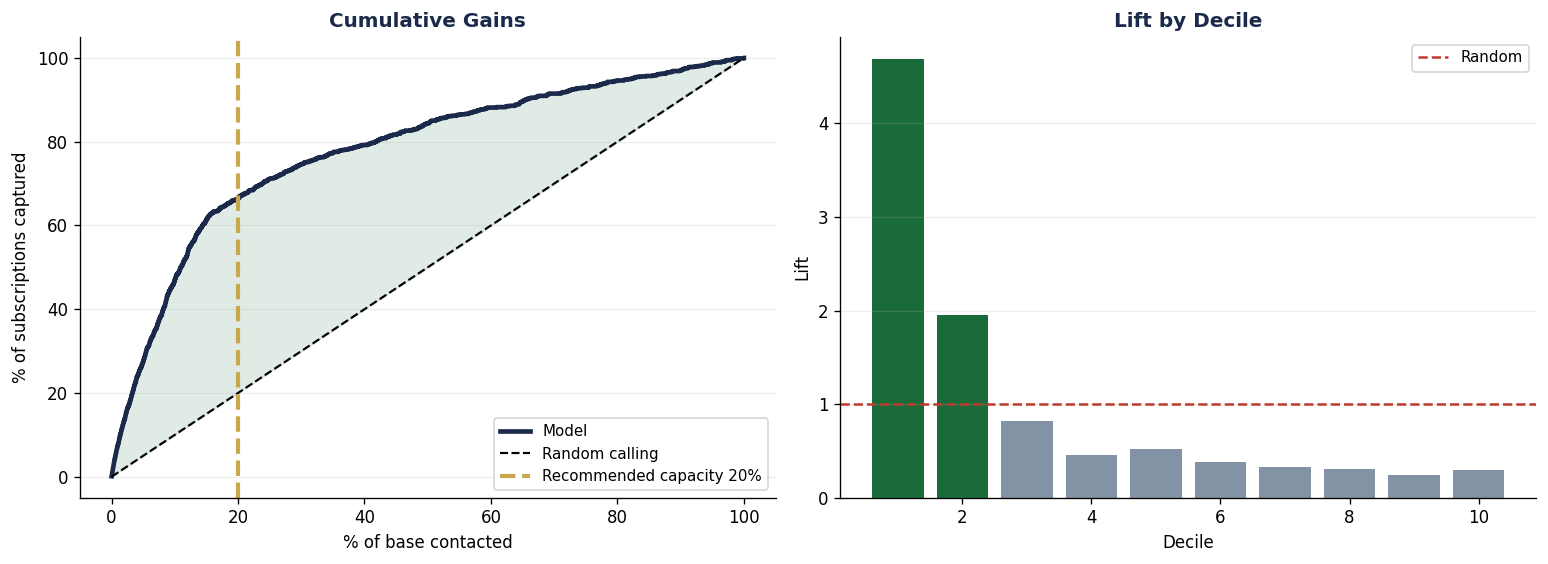

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
x=np.arange(1,n+1)/n; g=np.cumsum(ys)/ys.sum()
ax[0].plot(x*100,g*100,color=NAVY,lw=2.8,label='Model')
ax[0].plot([0,100],[0,100],'k--',lw=1.3,label='Random calling')
ax[0].fill_between(x*100,g*100,x*100,alpha=.13,color=GREEN)
ax[0].axvline(20,color=GOLD,lw=2.5,ls='--',label='Recommended capacity 20%')
ax[0].set_xlabel('% of base contacted'); ax[0].set_ylabel('% of subscriptions captured')
ax[0].set_title('Cumulative Gains', fontweight='bold', color=NAVY); ax[0].legend(fontsize=9)

d=pd.DataFrame(dec)
ax[1].bar(d.Decile,d.Lift,color=[GREEN if v>=1 else GREY for v in d.Lift])
ax[1].axhline(1,color=RED,ls='--',lw=1.5,label='Random')
ax[1].set_xlabel('Decile'); ax[1].set_ylabel('Lift'); ax[1].legend(fontsize=9)
ax[1].set_title('Lift by Decile', fontweight='bold', color=NAVY)
for a in ax: a.spines[['top','right']].set_visible(False); a.grid(alpha=.22,axis='y')
plt.tight_layout(); plt.show()

## 6. Sensitivity & Robustness

Three tests: does the ranking survive a realistic cost range, does it survive **time**, and where does
the signal actually come from?

In [11]:
print('COST SENSITIVITY — when does targeting beat calling everyone?\n')
for C in [5,10,20,30,40,50]:
    best_p, best_t = -1e9, None
    for t in np.arange(.02,.9,.01):
        pred=(p_gb>=t); tp=int((pred&(y_test==1)).sum()); ct=int(pred.sum())
        pr=tp*VALUE_SUB-ct*C
        if pr>best_p: best_p,best_t=pr,t
    call_all=y_test.sum()*VALUE_SUB-n*C
    print(f'  EUR{C:>3.0f}/contact -> t*={best_t:.2f} | targeted EUR{best_p:>8,.0f} | '
          f'call-all EUR{call_all:>9,.0f} | uplift EUR{best_p-call_all:>8,.0f}')

COST SENSITIVITY — when does targeting beat calling everyone?

  EUR  5/contact -> t*=0.04 | targeted EUR  98,550 | call-all EUR   98,020 | uplift EUR     530
  EUR 10/contact -> t*=0.07 | targeted EUR  78,720 | call-all EUR   56,840 | uplift EUR  21,880
  EUR 20/contact -> t*=0.15 | targeted EUR  61,440 | call-all EUR  -25,520 | uplift EUR  86,960
  EUR 30/contact -> t*=0.16 | targeted EUR  48,540 | call-all EUR -107,880 | uplift EUR 156,420
  EUR 40/contact -> t*=0.23 | targeted EUR  36,360 | call-all EUR -190,240 | uplift EUR 226,600
  EUR 50/contact -> t*=0.27 | targeted EUR  25,400 | call-all EUR -272,600 | uplift EUR 298,000


In [12]:
MACRO=['emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']

def evaluate(drop_macro, temporal):
    d=df.drop(columns=['y']+(MACRO if drop_macro else []))
    Xv=pd.get_dummies(d, drop_first=True)
    if temporal:   # data is ordered May 2008 -> Nov 2010
        c=int(len(Xv)*.8); a,b,c_,d_=Xv.iloc[:c],Xv.iloc[c:],y.iloc[:c],y.iloc[c:]
    else:
        a,b,c_,d_=train_test_split(Xv,y,test_size=.2,random_state=RANDOM_STATE,stratify=y)
    m=HistGradientBoostingClassifier(max_iter=300,learning_rate=.06,max_depth=6,
                                     random_state=RANDOM_STATE).fit(a,c_)
    return roc_auc_score(d_, m.predict_proba(b)[:,1])

print(f"{'Feature set':<28}{'Random split':>14}{'Temporal split':>16}")
print('-'*58)
print(f"{'All features':<28}{evaluate(False,False):>14.4f}{evaluate(False,True):>16.4f}")
print(f"{'Customer-only (no macro)':<28}{evaluate(True,False):>14.4f}{evaluate(True,True):>16.4f}")

Feature set                   Random split  Temporal split
----------------------------------------------------------


All features                        0.8145          0.6344


Customer-only (no macro)            0.7826          0.6833


### What the robustness tests reveal — the most important result in this project

A random train/test split reports **AUC 0.815**. Splitting the same data **chronologically** — train
on May 2008–early 2010, test on the months that follow — drops it to **0.634**.

The permutation-importance table explains why: the top two features are `nr.employed` and
`euribor3m`, macroeconomic series that trend over the campaign period. The model is substantially
learning **when in the economic cycle a call was placed**, not **who is a good prospect**. Because
those indicators drift, that knowledge does not transfer forward.

Removing the macro block costs little on a random split (0.815 → 0.783) but **improves** the temporal
result (0.634 → **0.683**). The customer-level signal is weaker in-sample and more durable out-of-sample.

**Implication for deployment.** Macro indicators are legitimately available at scoring time — this is
drift, not leakage — so the full model is usable. But its reported accuracy is optimistic, and it must
be retrained on a **quarterly** cadence. The customer-only model is the recommended fallback whenever
retraining lapses or macro conditions move sharply.

## 7. Recommendation

**Decision rule.** Score the eligible base with the gradient boosting model. Rank by predicted
probability. Route the **top 20%** to the calling queue. Apply a hard **cap of 4 contacts** per
customer per campaign (from the fatigue curve in Section 3, independent of the model).

**Expected performance** (test set, 8,236 customers):

| Capacity | Model subscriptions | Random calling | Lift |
|---|---|---|---|
| Top 10% | 435 (46.9% of all) | 93 | **4.69×** |
| **Top 20%** | **616 (66.4% of all)** | **186** | **3.32×** |
| Top 30% | 692 (74.6% of all) | 278 | 2.49× |

At 20% capacity the model captures **two-thirds of all available subscriptions using one-fifth of the
calls** — roughly **3.3× more subscriptions than random dialling at identical agent cost**.

**Pilot.** 8 weeks. Randomise the eligible base 50/50 into model-ranked and business-as-usual queues,
holding agent hours equal across arms. Primary KPI: subscriptions per 1,000 calls. Ship if the
model arm beats control by ≥ 2× with a contact cap in force.

**Three risks for the executive team**
1. **Temporal degradation.** In-sample AUC overstates forward performance (0.815 → 0.634). Retrain
   quarterly; alert if the customer-only fallback outperforms the full model.
2. **Fairness.** `age` and `job` are predictive, and life-stage groups (students, retired) are
   heavily favoured. Run a disparate-impact review before production; document that no protected
   attribute is used as a hard filter.
3. **Assumed economics.** €5/contact and €150/subscription are illustrative, not sourced from NovaBank
   finance. The capacity-based recommendation is robust to these values; any profit figure is not.

## 8. AI Usage Log

**Tool: Claude (Anthropic)**

| Contribution | Human judgment applied |
|---|---|
| Scaffolded preprocessing and model-comparison code | Chose which models to compare and all hyperparameters |
| Identified `duration` as leakage from dataset docs | Decided to drop it and to quantify the inflation explicitly |
| Suggested temporal-split robustness test | Interpreted the result and changed the recommendation because of it |
| Drafted memo and slide structure | All numbers, framing, risks and conclusions |
| Flagged that the brief's churn narrative did not match the linked dataset | Chose the reframe over fabricating a churn label |

**What I learned.** The threshold question I expected to be central turned out to be nearly irrelevant
once the cost-to-value ratio was made explicit — the real constraint was capacity, which changed the
whole framing from thresholds to ranking and lift. Separately, the gap between random-split and
temporal-split performance was a reminder that a good cross-validation score is not evidence a model
will work next quarter.

**Reproducibility.** `random_state=42` throughout. Run top to bottom with
`bank-additional-full.csv` beside the notebook.